# AI-Assisted Demand Forecasting Dashboard
### Anmol Zade | Business Analyst Portfolio Project
**Domain:** FMCG / Quick Commerce (Swiggy Instamart style)  
**Dataset:** Store Sales Time Series Forecasting — Kaggle (Favorita)  
**Goal:** Forecast weekly demand per category → feed into Power BI dashboard

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_percentage_error
import warnings
warnings.filterwarnings('ignore')

print('All libraries loaded successfully!')

All libraries loaded successfully!


Load & Explore Data

In [3]:
# Load raw data
df = pd.read_csv('train.csv', parse_dates=['date'])
stores = pd.read_csv('stores.csv')
holidays = pd.read_csv('holidays_events.csv', parse_dates=['date'])

print('Train shape:', df.shape)
print('Date range:', df['date'].min(), 'to', df['date'].max())
print('\nProduct Categories:')
print(df['family'].unique())
print('\nStores:', df['store_nbr'].nunique())
df.head()

Train shape: (3000888, 6)
Date range: 2013-01-01 00:00:00 to 2017-08-15 00:00:00

Product Categories:
['AUTOMOTIVE' 'BABY CARE' 'BEAUTY' 'BEVERAGES' 'BOOKS' 'BREAD/BAKERY'
 'CELEBRATION' 'CLEANING' 'DAIRY' 'DELI' 'EGGS' 'FROZEN FOODS' 'GROCERY I'
 'GROCERY II' 'HARDWARE' 'HOME AND KITCHEN I' 'HOME AND KITCHEN II'
 'HOME APPLIANCES' 'HOME CARE' 'LADIESWEAR' 'LAWN AND GARDEN' 'LINGERIE'
 'LIQUOR,WINE,BEER' 'MAGAZINES' 'MEATS' 'PERSONAL CARE' 'PET SUPPLIES'
 'PLAYERS AND ELECTRONICS' 'POULTRY' 'PREPARED FOODS' 'PRODUCE'
 'SCHOOL AND OFFICE SUPPLIES' 'SEAFOOD']

Stores: 54


,id,date,store_nbr,family,sales,onpromotion
0,0,2013-01-01,1,AUTOMOTIVE,0.0,0
1,1,2013-01-01,1,BABY CARE,0.0,0
2,2,2013-01-01,1,BEAUTY,0.0,0
3,3,2013-01-01,1,BEVERAGES,0.0,0
4,4,2013-01-01,1,BOOKS,0.0,0


Filter FMCG Categories & Aggregate Weekly

In [11]:
# Map to Swiggy Instamart style categories
fmcg_cats = ['DAIRY', 'BEVERAGES', 'BREAD/BAKERY', 'EGGS', 'FROZEN FOODS', 'PRODUCE', 'GROCERY I']
df_fmcg = df[df['family'].isin(fmcg_cats)].copy()

# Use last 2 years for relevance
df_fmcg = df_fmcg[df_fmcg['date'] >= '2015-01-01']

# Aggregate weekly across all stores (city-level demand)
df_weekly = df_fmcg.groupby(['date','family'])['sales'].sum().reset_index()
df_weekly = df_weekly.sort_values(['family','date'])

print('Cleaned shape:', df_weekly.shape)
df_weekly.to_csv('data/fmcg_weekly.csv', index=False)
print('Saved to data/fmcg_weekly.csv')
df_weekly.head(10)

Cleaned shape: (6692, 3)
Saved to data/fmcg_weekly.csv


,date,family,sales
0,2015-01-01,BEVERAGES,3528.0
7,2015-01-02,BEVERAGES,111353.0
14,2015-01-03,BEVERAGES,110296.0
21,2015-01-04,BEVERAGES,122463.0
28,2015-01-05,BEVERAGES,88624.0
35,2015-01-06,BEVERAGES,73243.0
42,2015-01-07,BEVERAGES,73468.0
49,2015-01-08,BEVERAGES,66253.0
56,2015-01-09,BEVERAGES,69734.0
63,2015-01-10,BEVERAGES,98179.0


Exploratory Data Analysis (EDA)

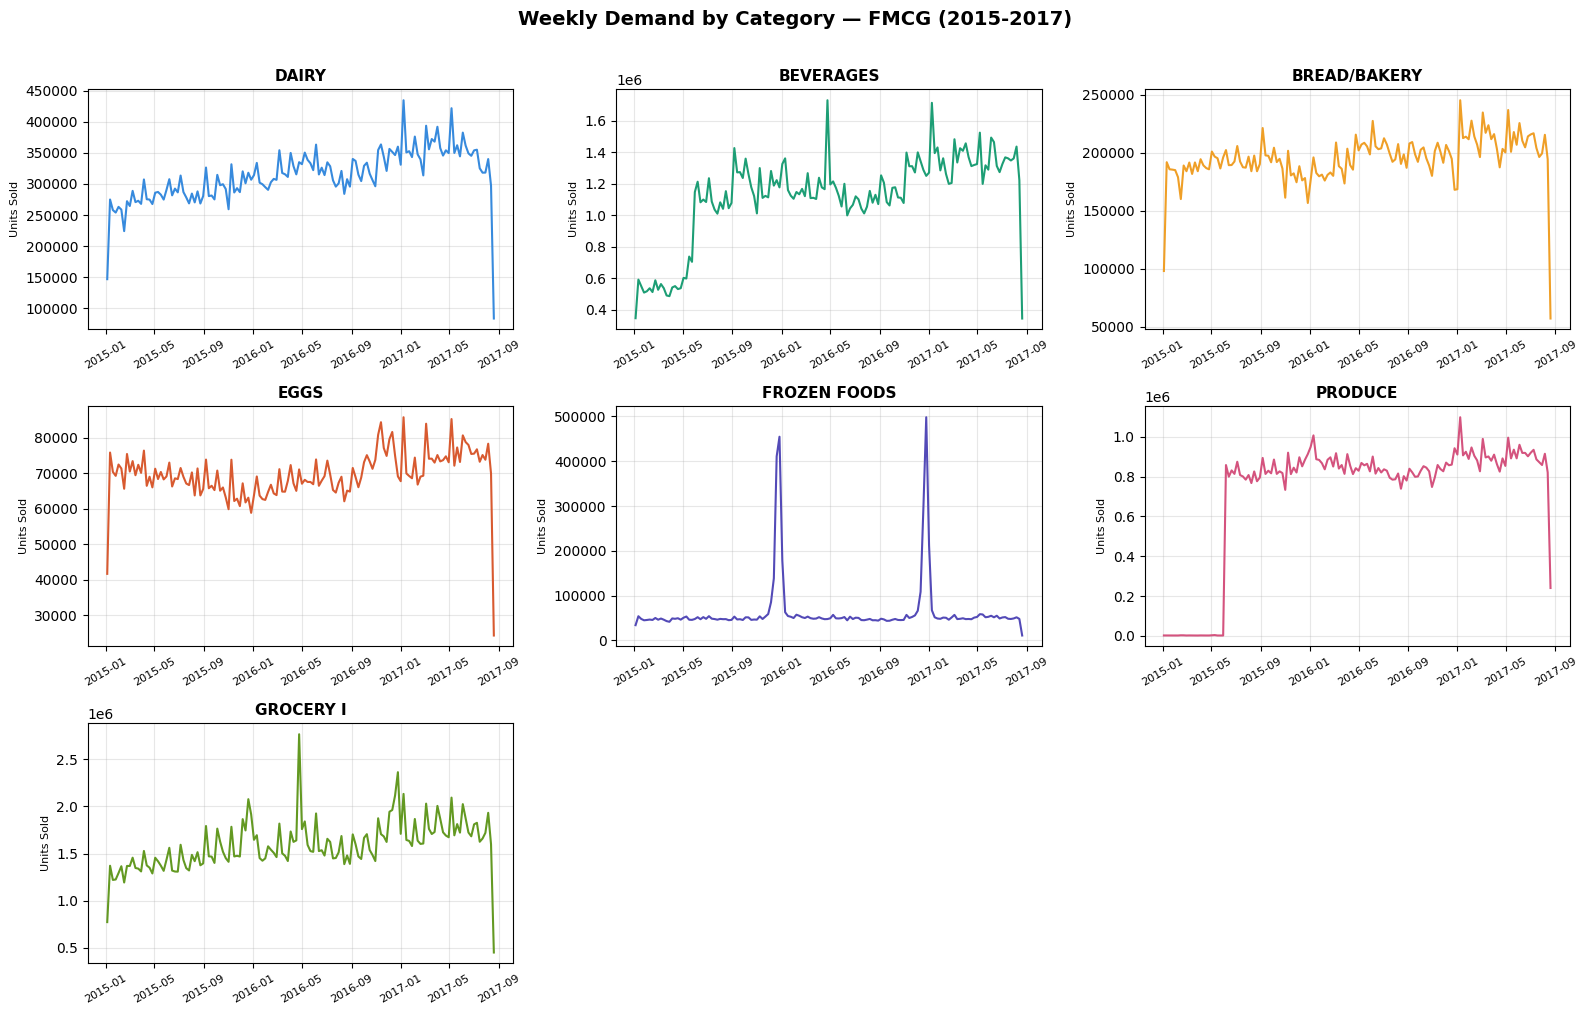

EDA chart saved!


In [12]:
fig, axes = plt.subplots(3, 3, figsize=(16, 10))
axes = axes.flatten()
colors = ['#378ADD','#1D9E75','#EF9F27','#D85A30','#534AB7','#D4537E','#639922']

for i, cat in enumerate(fmcg_cats):
    cat_df = df_weekly[df_weekly['family'] == cat].copy()
    cat_df = cat_df.set_index('date').resample('W')['sales'].sum()
    axes[i].plot(cat_df.index, cat_df.values, color=colors[i], linewidth=1.5)
    axes[i].set_title(cat, fontsize=11, fontweight='bold')
    axes[i].tick_params(axis='x', rotation=30, labelsize=8)
    axes[i].set_ylabel('Units Sold', fontsize=8)
    axes[i].grid(True, alpha=0.3)

for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Weekly Demand by Category — FMCG (2015-2017)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('charts/eda_demand_trends.png', dpi=150, bbox_inches='tight')
plt.show()
print('EDA chart saved!')

Feature Engineering
We create features that capture:
- **Trend** — overall growth over time
- **Seasonality** — sine/cosine waves to capture weekly/yearly patterns
- **Holiday effect** — whether the week contains a holiday
- **Lag features** — what sales were 4 and 8 weeks ago (autocorrelation)

In [13]:

holiday_dates = set(holidays['date'].dt.date)

def engineer_features(cat_df):
    cat_df = cat_df.copy().reset_index(drop=True)
    cat_df['week_num'] = cat_df['ds'].dt.isocalendar().week.astype(int)
    cat_df['month'] = cat_df['ds'].dt.month
    cat_df['trend'] = range(len(cat_df))
    cat_df['trend_sq'] = cat_df['trend'] ** 2
    cat_df['is_holiday_week'] = cat_df['ds'].apply(lambda x: int(x.date() in holiday_dates))
    # Fourier features for seasonality
    for k in [1, 2, 4]:
        cat_df[f'sin_{k}'] = np.sin(2 * np.pi * k * cat_df['week_num'] / 52)
        cat_df[f'cos_{k}'] = np.cos(2 * np.pi * k * cat_df['week_num'] / 52)
    # Lag features (memory of past demand)
    cat_df['lag_4'] = cat_df['y'].shift(4)
    cat_df['lag_8'] = cat_df['y'].shift(8)
    cat_df['rolling_4'] = cat_df['y'].shift(1).rolling(4).mean()
    return cat_df.dropna().reset_index(drop=True)

FEATURES = ['trend','trend_sq','sin_1','cos_1','sin_2','cos_2','sin_4','cos_4',
            'month','is_holiday_week','lag_4','lag_8','rolling_4']

print('Feature list:', FEATURES)
print('Total features:', len(FEATURES))

Feature list: ['trend', 'trend_sq', 'sin_1', 'cos_1', 'sin_2', 'cos_2', 'sin_4', 'cos_4', 'month', 'is_holiday_week', 'lag_4', 'lag_8', 'rolling_4']
Total features: 13


Train Model & Forecast (All Categories)

In [14]:
df_weekly = pd.read_csv('data/fmcg_weekly.csv', parse_dates=['date'])
forecast_rows = []
actual_rows = []
accuracy_rows = []

for cat in fmcg_cats:
    # Prep data
    cat_df = df_weekly[df_weekly['family'] == cat].copy()
    cat_df = cat_df.set_index('date').resample('W')['sales'].sum().reset_index()
    cat_df.columns = ['ds', 'y']
    cat_df = cat_df[cat_df['y'] > 0].copy()
    cat_df = engineer_features(cat_df)

    # Train / Test split — last 8 weeks as test
    split = len(cat_df) - 8
    train, test = cat_df[:split], cat_df[split:]

    # Scale + Train Ridge Regression
    scaler = StandardScaler()
    X_train = scaler.fit_transform(train[FEATURES])
    X_test  = scaler.transform(test[FEATURES])
    model = Ridge(alpha=1.0)
    model.fit(X_train, train['y'])

    # Accuracy
    pred_test = np.maximum(model.predict(X_test), 0)
    mape = mean_absolute_percentage_error(test['y'].values, pred_test)
    acc  = round((1 - mape) * 100, 1)
    accuracy_rows.append({'Category': cat, 'Accuracy_%': acc, 'MAPE_%': round(mape*100,1)})

    # Save actuals (last 20 weeks for chart)
    for _, row in cat_df.tail(20).iterrows():
        actual_rows.append({'Date': row['ds'].strftime('%Y-%m-%d'), 'Category': cat,
                            'Actual': round(row['y'], 0)})

    # Forecast next 8 weeks
    last_row = cat_df.iloc[-1]
    future_dates = pd.date_range(cat_df['ds'].max() + pd.Timedelta(weeks=1), periods=8, freq='W')
    for i, d in enumerate(future_dates):
        t = len(cat_df) + i
        wk = d.isocalendar().week
        row_feats = [t, t**2,
            np.sin(2*np.pi*1*wk/52), np.cos(2*np.pi*1*wk/52),
            np.sin(2*np.pi*2*wk/52), np.cos(2*np.pi*2*wk/52),
            np.sin(2*np.pi*4*wk/52), np.cos(2*np.pi*4*wk/52),
            d.month, 0, last_row['lag_4'], last_row['lag_8'], last_row['rolling_4']]
        X_fut = scaler.transform([row_feats])
        yhat  = max(float(model.predict(X_fut)[0]), 0)
        forecast_rows.append({
            'Date': d.strftime('%Y-%m-%d'), 'Category': cat,
            'Forecast': round(yhat, 0),
            'Lower_Band': round(yhat * 0.91, 0),
            'Upper_Band': round(yhat * 1.09, 0)
        })

    print(f'{cat:15s} → Accuracy: {acc}%')

# Save all outputs
pd.DataFrame(actual_rows).to_csv('data/actuals_output.csv', index=False)
pd.DataFrame(forecast_rows).to_csv('data/forecast_output.csv', index=False)
acc_df = pd.DataFrame(accuracy_rows)
acc_df.to_csv('data/model_accuracy.csv', index=False)

print('\n=== MODEL ACCURACY SUMMARY ===')
print(acc_df.to_string(index=False))
print(f'\nOverall Average Accuracy: {round(acc_df["Accuracy_%"].mean(), 1)}%')

DAIRY           → Accuracy: 54.2%
BEVERAGES       → Accuracy: 59.6%
BREAD/BAKERY    → Accuracy: 62.1%
EGGS            → Accuracy: 70.0%
FROZEN FOODS    → Accuracy: -3.5%
PRODUCE         → Accuracy: 65.2%
GROCERY I       → Accuracy: 60.5%

=== MODEL ACCURACY SUMMARY ===
    Category  Accuracy_%  MAPE_%
       DAIRY        54.2    45.8
   BEVERAGES        59.6    40.4
BREAD/BAKERY        62.1    37.9
        EGGS        70.0    30.0
FROZEN FOODS        -3.5   103.5
     PRODUCE        65.2    34.8
   GROCERY I        60.5    39.5

Overall Average Accuracy: 52.6%


Visualize: Actual vs Forecast

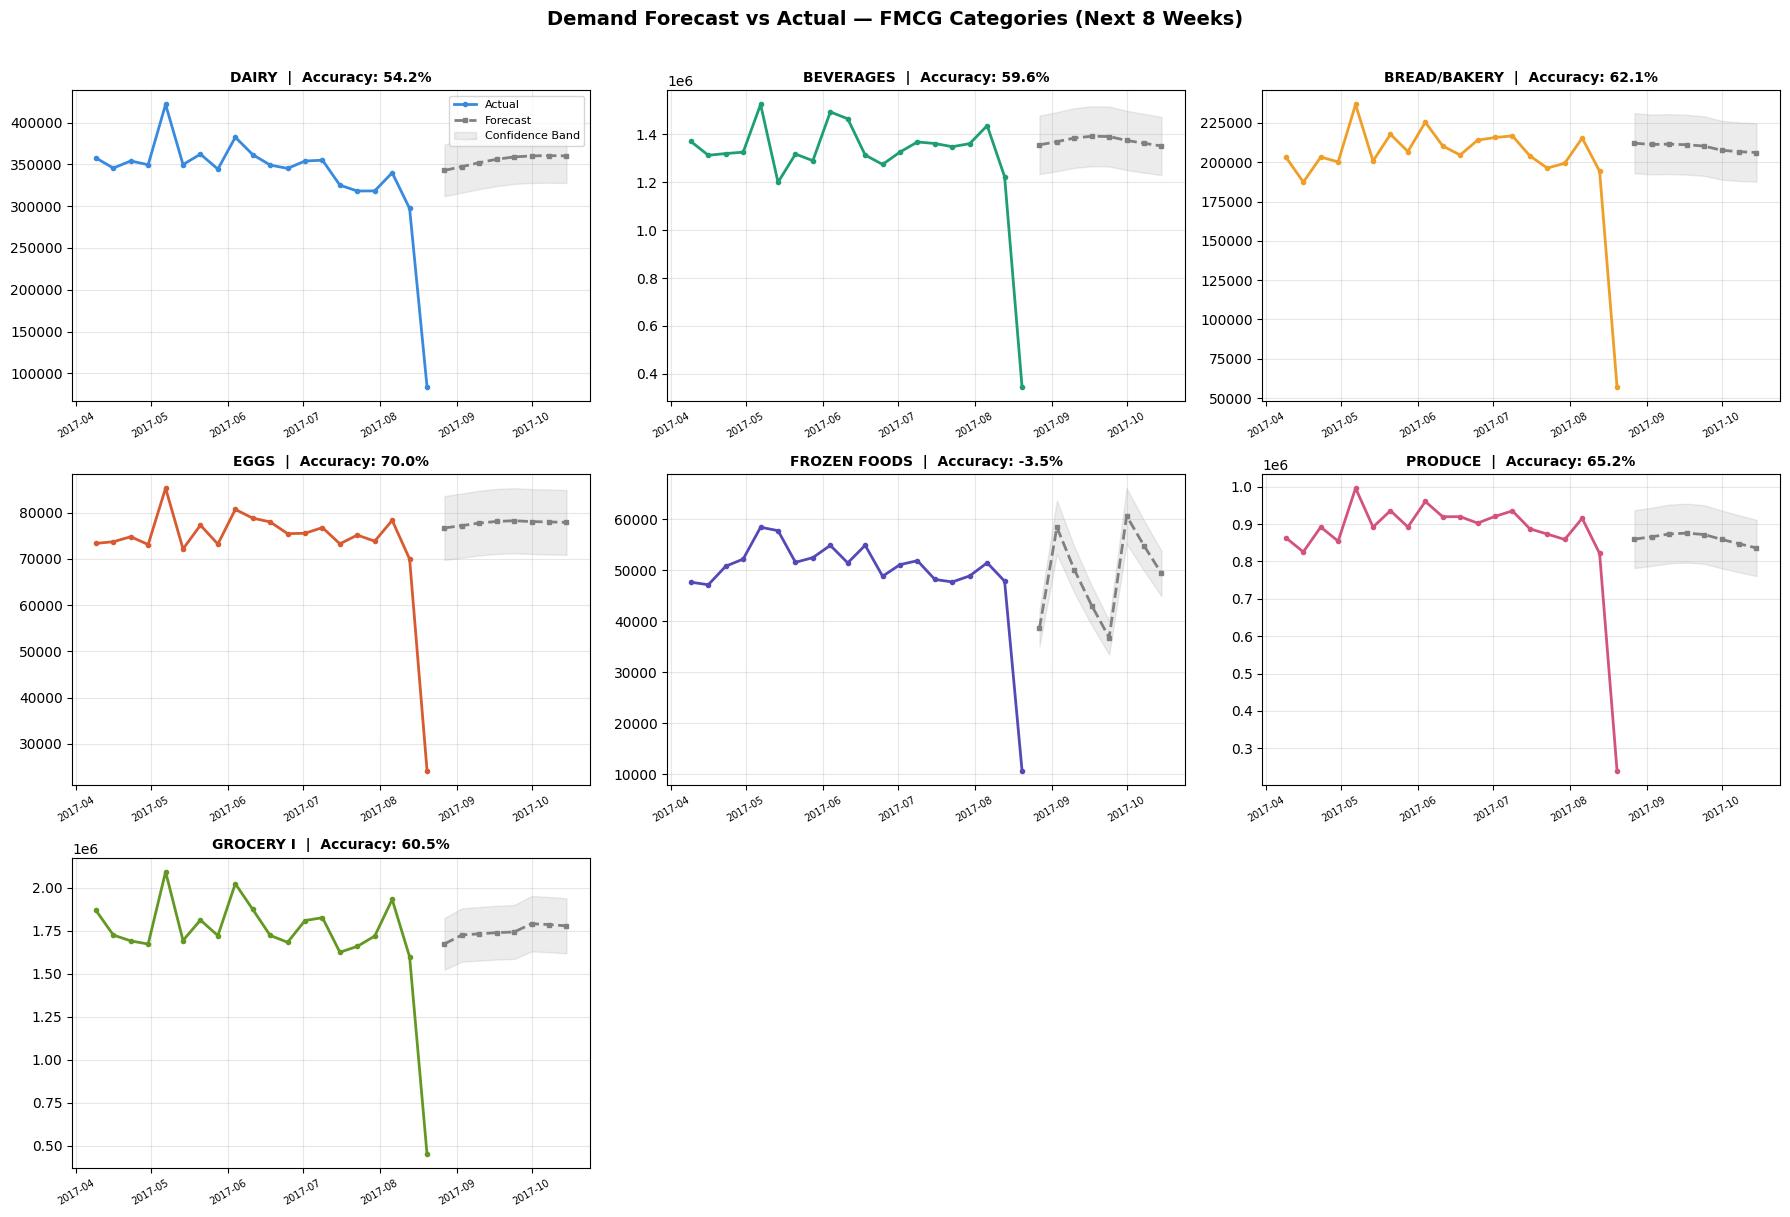

Chart saved to charts/forecast_vs_actual.png


In [15]:
actuals_df  = pd.read_csv('data/actuals_output.csv', parse_dates=['Date'])
forecast_df = pd.read_csv('data/forecast_output.csv', parse_dates=['Date'])

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()
colors = ['#378ADD','#1D9E75','#EF9F27','#D85A30','#534AB7','#D4537E','#639922']

for i, cat in enumerate(fmcg_cats):
    ax = axes[i]
    a = actuals_df[actuals_df['Category'] == cat].sort_values('Date')
    f = forecast_df[forecast_df['Category'] == cat].sort_values('Date')
    
    ax.plot(a['Date'], a['Actual'], color=colors[i], linewidth=2, label='Actual', marker='o', markersize=3)
    ax.plot(f['Date'], f['Forecast'], color='gray', linewidth=2, linestyle='--', label='Forecast', marker='s', markersize=3)
    ax.fill_between(f['Date'], f['Lower_Band'], f['Upper_Band'], color='gray', alpha=0.15, label='Confidence Band')
    
    acc_val = acc_df[acc_df['Category']==cat]['Accuracy_%'].values[0]
    ax.set_title(f'{cat}  |  Accuracy: {acc_val}%', fontsize=10, fontweight='bold')
    ax.tick_params(axis='x', rotation=30, labelsize=7)
    ax.grid(True, alpha=0.3)
    if i == 0: ax.legend(fontsize=8)

for j in range(i+1, len(axes)): axes[j].set_visible(False)

plt.suptitle('Demand Forecast vs Actual — FMCG Categories (Next 8 Weeks)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('charts/forecast_vs_actual.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved to charts/forecast_vs_actual.png')

SKU Inventory Table (Instamart Style)

In [16]:
sku_df = pd.read_csv('data/sku_inventory.csv')

# Color code for display
def highlight_status(val):
    if val == 'Stockout Risk': return 'background-color: #FCEBEB; color: #A32D2D; font-weight: bold'
    elif val == 'Overstocked': return 'background-color: #FAEEDA; color: #854F0B; font-weight: bold'
    return 'background-color: #EAF3DE; color: #3B6D11; font-weight: bold'

styled = sku_df.style.applymap(highlight_status, subset=['Status'])
print(f'Total SKUs: {len(sku_df)}')
print(f'Stockout Risk: {len(sku_df[sku_df["Status"]=="Stockout Risk"])}')
print(f'Overstocked:   {len(sku_df[sku_df["Status"]=="Overstocked"])}')
print(f'Overstock Value: ₹{sku_df["Overstock_Value_INR"].sum():,}')
styled

Total SKUs: 12
Stockout Risk: 5
Overstocked:   3
Overstock Value: ₹81,000


,SKU,Category,Current_Stock,Forecast_7D,Coverage_Days,Status,Action,Overstock_Value_INR
0,Amul Full Cream Milk 1L,DAIRY,980,2400,2.900000,Stockout Risk,Reorder Now,0
1,Nandini Curd 400g,DAIRY,650,800,5.700000,Normal,On Track,0
2,Lay's Classic Salted 50g,BEVERAGES,420,1800,1.200000,Stockout Risk,Reorder Now,0
3,Britannia Good Day 80g,BREAD/BAKERY,1100,900,8.600000,Normal,On Track,0
4,Whole Wheat Bread 400g,BREAD/BAKERY,280,950,2.100000,Stockout Risk,Reorder Now,0
5,Basmati Rice 5kg,GROCERY I,4100,1600,17.900000,Overstocked,Promote/Bundle,41000
6,Aashirvaad Atta 5kg,GROCERY I,2200,1100,14.000000,Overstocked,Promote/Bundle,28000
7,Tomatoes 1kg,PRODUCE,740,1200,4.300000,Normal,On Track,0
8,Fresh Spinach 250g,PRODUCE,190,880,1.500000,Stockout Risk,Reorder Now,0
9,Lays Cream Onion 26g,BEVERAGES,1800,700,18.000000,Overstocked,Promote/Bundle,12000


Files Ready for Power BI
Load these 3 CSV files into Power BI Desktop:

| File | Use in Power BI |
|------|----------------|
| `data/actuals_output.csv` | Line chart — Actual demand |
| `data/forecast_output.csv` | Line chart — Forecast + confidence band |
| `data/sku_inventory.csv` | Table visual with conditional formatting |
| `data/model_accuracy.csv` | KPI cards — accuracy per category |

**DAX formula for Forecast Accuracy KPI card:**
```
Avg Accuracy = AVERAGE('model_accuracy'[Accuracy_%])
```

**DAX for Coverage Days conditional column:**
```
Status Color = 
IF([Coverage_Days] < 3, "Red", 
   IF([Coverage_Days] > 12, "Amber", "Green"))
```

In [18]:
import os
print('=== ALL OUTPUT FILES ===')
for f in os.listdir('data'):
    size = os.path.getsize(f'data/{f}')
    print(f'  data/{f}  ({size:,} bytes)')
print('\nProject complete! Load CSV files into Power BI to build the dashboard.')

=== ALL OUTPUT FILES ===
  data/actuals_output.csv  (4,258 bytes)
  data/fmcg_weekly.csv  (208,386 bytes)
  data/forecast_output.csv  (2,750 bytes)
  data/model_accuracy.csv  (171 bytes)
  data/sku_inventory.csv  (914 bytes)

Project complete! Load CSV files into Power BI to build the dashboard.
